# Predicting MPG — Multivariate Linear Regression from Scratch

Gradient descent linear regression implemented without scikit-learn, using the [Auto MPG dataset](https://archive.ics.uci.edu/dataset/9/auto+mpg) (UCI).

Five features are used — `horsepower`, `horsepower²`, `model_year`, `weight`, and `weight²` — so the fit curves with respect to horsepower and weight while staying linear in `model_year` (the model is linear in its parameters `w, b`, even though it's quadratic in horsepower and weight).

**Model:** $f(\mathbf{x}) = \mathbf{w}\cdot\mathbf{x} + b = \sum_j w_jx_j + b$
**Cost:** $J = \frac{1}{2m}\sum (f(x)-y)^2$
**Gradients:** $\frac{\partial J}{\partial w_j} = \frac{1}{m}\sum(f(x)-y)x_j$, $\frac{\partial J}{\partial b} = \frac{1}{m}\sum(f(x)-y)$
**Update:** $w \mathrel{-}= \alpha\frac{\partial J}{\partial w}$, $b \mathrel{-}= \alpha\frac{\partial J}{\partial b}$

In [231]:
pip install ucimlrepo

Note: you may need to restart the kernel to use updated packages.


Installs `ucimlrepo` to fetch the dataset directly from the UCI repository.

In [232]:
pip install seaborn

Note: you may need to restart the kernel to use updated packages.


Installs `seaborn`, used for the plots below.

In [233]:
from ucimlrepo import fetch_ucirepo 

  
# fetch dataset 
auto_mpg = fetch_ucirepo(id=9) 
  
# data (as pandas dataframes) 
X = auto_mpg.data.features 
y = auto_mpg.data.targets 
  
# metadata 
print(auto_mpg.metadata) 
  
# variable information 
print(auto_mpg.variables) 

{'uci_id': 9, 'name': 'Auto MPG', 'repository_url': 'https://archive.ics.uci.edu/dataset/9/auto+mpg', 'data_url': 'https://archive.ics.uci.edu/static/public/9/data.csv', 'abstract': 'Revised from CMU StatLib library, data concerns city-cycle fuel consumption', 'area': 'Other', 'tasks': ['Regression'], 'characteristics': ['Multivariate'], 'num_instances': 398, 'num_features': 7, 'feature_types': ['Real', 'Categorical', 'Integer'], 'demographics': [], 'target_col': ['mpg'], 'index_col': ['car_name'], 'has_missing_values': 'yes', 'missing_values_symbol': 'NaN', 'year_of_dataset_creation': 1993, 'last_updated': 'Thu Aug 10 2023', 'dataset_doi': '10.24432/C5859H', 'creators': ['R. Quinlan'], 'intro_paper': None, 'additional_info': {'summary': 'This dataset is a slightly modified version of the dataset provided in the StatLib library.  In line with the use by Ross Quinlan (1993) in predicting the attribute "mpg", 8 of the original instances were removed because they had unknown values for th

Loads the Auto MPG dataset (id=9) into `X` (features) and `y` (target = `mpg`).

In [234]:
import numpy as np
import pandas as pd
import seaborn as sns

Standard imports: `numpy` for the math, `pandas` for the DataFrame, `seaborn` for the plots.

In [235]:
df = pd.concat([X, y], axis=1)

Combines features and target into a single DataFrame.

In [236]:
df = df.dropna()
df

,displacement,cylinders,horsepower,weight,acceleration,model_year,origin,mpg
0,307.0,8,130.0,3504,12.0,70,1,18.0
1,350.0,8,165.0,3693,11.5,70,1,15.0
2,318.0,8,150.0,3436,11.0,70,1,18.0
3,304.0,8,150.0,3433,12.0,70,1,16.0
4,302.0,8,140.0,3449,10.5,70,1,17.0
...,...,...,...,...,...,...,...,...
393,140.0,4,86.0,2790,15.6,82,1,27.0
394,97.0,4,52.0,2130,24.6,82,2,44.0
395,135.0,4,84.0,2295,11.6,82,1,32.0
396,120.0,4,79.0,2625,18.6,82,1,28.0


Drops rows with missing `horsepower` (398 → 392 rows).

In [253]:
df['hpsq'] = df['horsepower'] ** 2
df['hpsq'] = df['hpsq'] / df['hpsq'].mean()
df['weightsq'] = df['weight'] ** 2
df['weightsq'] = df['weightsq'] / df['weightsq'].mean()

Adds `horsepower²` and `weight²` (`hpsq`, `weightsq`) as extra features, each scaled by its own mean — this is what lets the fit curve instead of staying a straight line in horsepower and weight.

In [238]:
df['horsepower_'] = df['horsepower'] / df['horsepower'].mean()
df['mpg_'] = df['mpg'] / df['mpg'].mean()
df['model_year_'] = df['model_year'] / df['model_year'].mean()
df['weight_'] = df['weight'] / df['weight'].mean()

Scales `horsepower`, `mpg`, `model_year`, and `weight` by their means too (into new `_`-suffixed columns), so all inputs sit on a similar scale — this helps gradient descent converge evenly across every weight.

In [254]:
horsepower = df['horsepower_'].to_numpy()
hpsq = df['hpsq'].to_numpy()
mpg = df['mpg_'].to_numpy()
model_year = df['model_year_'].to_numpy()
weight = df['weight_'].to_numpy()
weightsq = df['weightsq'].to_numpy()

Converts the five normalized feature columns and the target to numpy arrays for the vectorized math below.

In [255]:
X = np.column_stack((horsepower, hpsq, model_year, weight, weightsq))
y = mpg.reshape(-1, 1)

Stacks the five features (`horsepower`, `hpsq`, `model_year`, `weight`, `weightsq`) into a single `X` matrix — one column per feature — and reshapes `mpg` into a column vector `y`. This is what makes the model generalize to any number of features instead of being hardcoded to two.

In [241]:
def Calculate_fwx(X, w, b):
    return np.sum(w*X, axis=1, keepdims=True) + b

**Model function `Calculate_fwx`:** $f(\mathbf{x}) = \sum_j w_jx_j + b$, computed for every example at once via broadcasting (`w*X` then summed across features).

In [242]:
def Calculate_cost(X, y, w, b):
    m = X.shape[0]
    fwx = Calculate_fwx(X, w, b)
    cost = fwx - y
    costsq = cost ** 2
    total = np.sum(costsq) / (2*m)
    return total


**Cost function `Calculate_cost`:** mean squared error, halved — the quantity gradient descent minimizes.

In [243]:
def Calculate_gradient(X, y, w, b):
    m = X.shape[0]
    fwx = Calculate_fwx(X, w, b)
    cost = fwx - y

    total = np.sum(cost)
    dj_db = total / m

    total = cost*X
    total = np.sum(total, axis=0, keepdims=True)
    dj_dw = total / m


    return dj_dw, dj_db

**`Calculate_gradient`:** returns both $\frac{\partial J}{\partial w}$ (a vector, one entry per feature) and $\frac{\partial J}{\partial b}$ in a single pass — unlike computing each weight's gradient separately, this scales to any number of features.

In [244]:
def Gradient_descent(X, y, alpha, num_iters):
    m = X.shape[0]
    cost_history = []

    w = np.zeros((1, X.shape[1]))
    b = 0

    for i in range(num_iters):

        dj_dw, dj_db = Calculate_gradient(X, y, w, b)

        w = w - alpha * dj_dw
        b = b - alpha * dj_db

        if(i%10 == 0):
            cost = Calculate_cost(X, y, w, b)
            cost_history.append(cost)

    return w, b, cost_history


**`Gradient_descent`:** the training loop. `w` starts as a zero vector sized to `X`'s number of features, so it adapts automatically to however many columns `X` has. Each iteration updates `w` and `b` together, and the cost is logged to `cost_history` every 10 iterations.

In [256]:
w, b, cost_history = Gradient_descent(X, y, 0.1, 20000)

Trains for 20,000 iterations at `alpha=0.1`.

<Axes: >

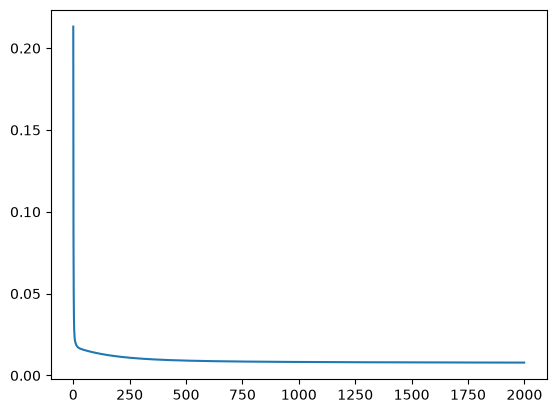

In [257]:
sns.lineplot(x=np.arange(2000), y=cost_history)

Plots `cost_history` over training — since cost is only logged every 10 iterations, the x-axis (0–1999) is measured in logged steps, not raw iterations. It should drop steeply at first and flatten out as gradient descent converges toward the minimum.

In [247]:
f = Calculate_fwx(X, w, b)
f = f.flatten()

Computes the model's predictions `f` for every example, then flattens it to 1-D for plotting.

<Axes: >

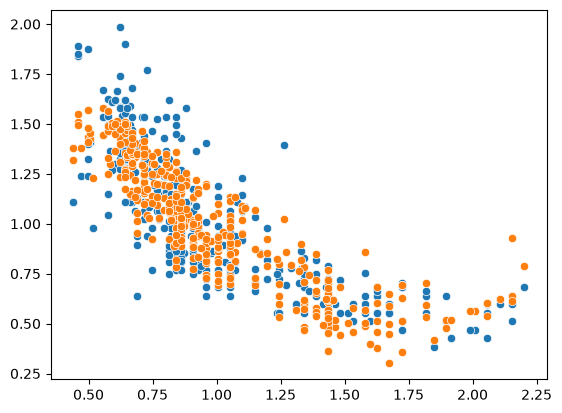

In [258]:
sns.scatterplot(x=horsepower, y=mpg)
sns.scatterplot(x=horsepower, y=f)

Plots the actual normalized `mpg` against `horsepower`, overlaid with the model's predictions `f` — a visual check of the fit along the horsepower axis.

<Axes: >

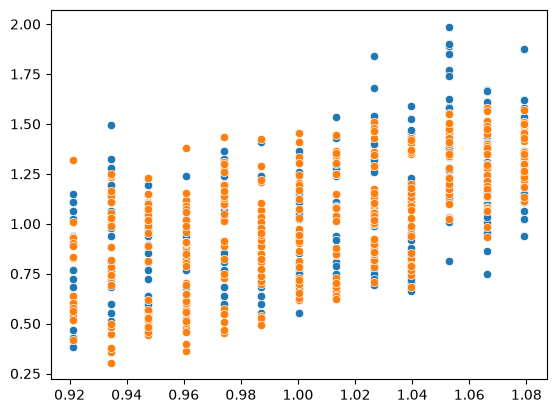

In [259]:
sns.scatterplot(x=model_year, y=mpg)
sns.scatterplot(x=model_year, y=f)

Same check along the `model_year` axis.

<Axes: >

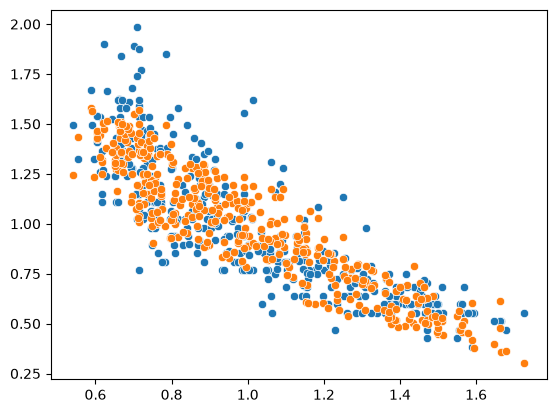

In [260]:
sns.scatterplot(x=weight, y=mpg)
sns.scatterplot(x=weight, y=f)

Same check along the `weight` axis.

In [261]:
print(w, b)

[[-0.90653091  0.35153025  2.37941788 -1.6021235   0.49074606]] 0.2870464440351196


Final trained parameters, in column order (`horsepower`, `hpsq`, `model_year`, `weight`, `weightsq`): `w ≈ [-0.907, 0.352, 2.379, -1.602, 0.491]`, `b ≈ 0.287`. The signs make sense: mpg drops with horsepower and weight, but the positive squared terms curve that drop back up, and the positive `model_year` weight captures newer cars being more fuel-efficient.

---
*This documentation was written by AI (Claude); all the modeling code above is my own.*